# 🌊 BinWaves Duke (Propagation)

> **Inputs:**
> - Bathymetry file in `.nc` format, located in the `inputs/` folder.  
>
> **ℹ️ NOTE:** If bathymetry data for the study area is not available, free GEBCO bathymetry (~400 m resolution) can be used:
> - **Download GEBCO bathymetry data:** [https://download.gebco.net/](https://download.gebco.net/)
> - Example notebook for working with GEBCO data:  
>   [Download_GEBCO_Bathymetry_Data.ipynb](https://github.com/GeoOcean/BlueMath/blob/clean/binwaves/toolkit/data/Download_GEBCO_Bathymetry_Data.ipynb)
>
> **Outputs:**
> - SWAN case configuration in `.csv` format.
> - `Kp_coefficients.nc` file saved in the `outputs/` folder.
> 
> Create this `outputs/` folder if not available!

### BinWaves Notebooks Overview

This Jupyter Notebook is the first of three in the **BinWaves** modeling workflow, following Cagigal et al., 2024 :

1. `BinWaves_Propagation.ipynb`  
2. `BinWaves_Reconstruction.ipynb`  
3. `BinWaves_Validation.ipynb`

---

#### Before You Start

Make sure you have:

- Installed the latest version of `bluemath-tk`:  
  ```bash
  pip install bluemath-tk[waves]
  ```
 
---

<details open>
<summary><strong>📁 BinWaves_Propagation.ipynb</strong></summary>

This notebook constructs and runs the **library of pre-run cases** for all **monochromatic wave systems**.

</details>

---

<details>
<summary><strong>📁 BinWaves_Reconstruction.ipynb</strong></summary>

This notebook reconstructs **wave conditions** using **offshore directional wave spectra**.

##### Requirements:

- Offshore wave spectrum data (e.g., **CAWCR** or **ERA5** datasets).

- **OPTIONAL 1**: Apply **satellite corrections** to the hindcast spectrum before running BinWaves using the `CalVal` tool in the BlueMath toolkit. An example is provided in the Jupyter Notebook **P00A_CalVal_Carolinas_CAWCR_4469.ipynb**.

- **OPTIONAL 2**: A **Super Point Spectrum** can be also used as input to the hindcast spectrum before running BinWaves. The `SuperPoint` aggregates the energy from a number of points (Wave Spectra) surrounding the study site (Cagigal et al., 2021).  An example is provided in the Jupyter Notebook **Super Point Computation** .

</details>

---

<details>
<summary><strong>📁 BinWaves_Validation.ipynb</strong></summary>

This notebook performs **validation** using **wave buoy data**, if available.

##### Requirements:

- Wave buoy data in a format compatible with BinWaves (if available).
- Some wave buoy data can be freely downloaded from:  
  🌊 [https://www.ndbc.noaa.gov/](https://www.ndbc.noaa.gov/)

- **NOTE:** You can use the `NDBC_buoy_data.ipynb` notebook to:
  - Download the buoy data.
  - Convert it into the appropriate format for BinWaves.

</details>

### 📌 In This Notebook: `BinWaves_Propagation.ipynb`

This notebook handles the **construction of the wave propagation library** by simulating wave cases.

### Steps:

- Generate wave conditions for all specified **frequencies** and **directions**.
- Set up and run SWAN simulations.
- Extract and save outputs from each simulation.
- Visualize the full wave library, including larger illustrative examples.

> ⚠️ **Coordinate System Note**  
> The BinWaves (SWAN) model can run in either **Spherical** or **Cartesian** coordinates:
> - Use **spherical coordinates** for areas larger than **100 km**.
> - Make sure your bathymetry file matches the coordinate system used in your simulation.

## Generate computational bathymetry

> ⚠️ **NOTE**  
> 
> - Functions expect coordinate columns to follow standard naming conventions.
> - For geographic coordinates, use: 'lon', 'lat', 'longitude', or 'latitude'.
> - For UTM coordinates, use: 'x', 'y', 'X', 'Y', 'cx', 'cy', 'easting', or 'northing'.
> - Ensure your data uses one of these names—otherwise, rename the coordinates accordingly
> - The bathymetry should have positive values for sea and negative values for land.

In [20]:
import xarray as xr
from utils.plotting import detect_coordinate_system

ds = xr.open_dataset("../../../../toolkit/data/outputs/GEBCO_-124.8_-123.8_44_45.nc")

coords = detect_coordinate_system(ds)
is_geographic = coords["is_geographic"]
x_coord = coords["x_coord"]
y_coord = coords["y_coord"]

bathy = -(ds.transpose(y_coord, x_coord).sortby(y_coord, ascending=False).elevation)

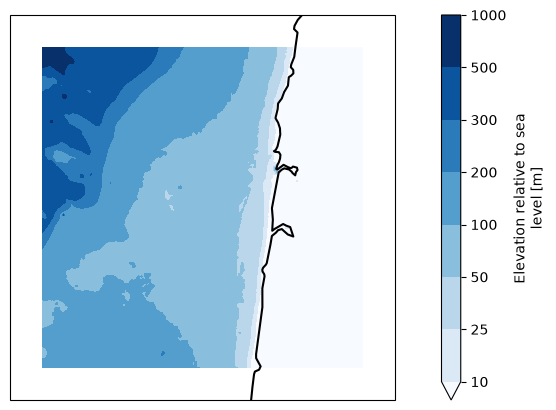

In [21]:
from utils.plotting import plot_selected_bathy

plot_selected_bathy(bathy=bathy, buoys=None)

## SWAN Grid Parameters

This section defines the computational grid for running the SWAN model:

- **`xpc`, `ypc`**: Origin coordinates of the grid (in meters for Cartesian, degrees for spherical).  
  - Default = `0.0` for Cartesian; required for spherical.

- **`alpc`**: Angle of the positive x-axis (degrees, Cartesian convention).  
  - Default = `0.0`.

- **`xlenc`, `ylenc`**: Grid length in the x- and y-directions.  
  - Units: meters (Cartesian), degrees (spherical).  

- **`mxc`, `myc`**: Number of grid cells in x- and y-directions (1 less than number of grid points).  
  - In 1D mode, `myc` = `0`.

<center>
    <img src="./assets/SWAN_grid.png" width="80%">
</center>

In [22]:
# COMPUTATIONAL GRID PARAMETERS
from bluemath_tk.topo_bathy.swan_grid import generate_grid_parameters

alpc = 0
grid_parameters = generate_grid_parameters(bathy, alpc)
grid_parameters

{'xpc': -124.79791666666667,
 'ypc': 44.00208333333333,
 'alpc': 0,
 'xlenc': 0.9958333333333229,
 'ylenc': 0.9958333333333371,
 'mxc': 239,
 'myc': 239,
 'xpinp': -124.79791666666667,
 'ypinp': 44.00208333333333,
 'alpinp': 0,
 'mxinp': 239,
 'myinp': 239,
 'dxinp': 0.004166666666662877,
 'dyinp': 0.004166666666662877}

## Desired locations for Model outputs

> ⚠️ **NOTE**  
> 
> - Output location spacing (out_dx, out_dy) can be specified. If not provided, the output locations will use the same spacing as the SWAN grid. However, for large domains or very fine SWAN grids, it is recommended to decrease the output spacing to reduce computational cost, at least at tasting stages.

In [23]:
# OUTPUT GRID LOCATIONS (KPS)
import numpy as np
from utils.operations import locations_grid_outputs

locations = locations_grid_outputs(grid_parameters, out_dx=0.15, out_dy=0.15)
# Combine grid locations with buoy locations
# buoy_coords = np.array(list(buoys_geo.values()))
locations = np.vstack((locations))#, buoy_coords))
locations

array([[-124.79791667,   44.00208333],
       [-124.65565476,   44.00208333],
       [-124.51339286,   44.00208333],
       [-124.37113095,   44.00208333],
       [-124.22886905,   44.00208333],
       [-124.08660714,   44.00208333],
       [-123.94434524,   44.00208333],
       [-123.80208333,   44.00208333],
       [-124.79791667,   44.14434524],
       [-124.65565476,   44.14434524],
       [-124.51339286,   44.14434524],
       [-124.37113095,   44.14434524],
       [-124.22886905,   44.14434524],
       [-124.08660714,   44.14434524],
       [-123.94434524,   44.14434524],
       [-123.80208333,   44.14434524],
       [-124.79791667,   44.28660714],
       [-124.65565476,   44.28660714],
       [-124.51339286,   44.28660714],
       [-124.37113095,   44.28660714],
       [-124.22886905,   44.28660714],
       [-124.08660714,   44.28660714],
       [-123.94434524,   44.28660714],
       [-123.80208333,   44.28660714],
       [-124.79791667,   44.42886905],
       [-124.65565476,   

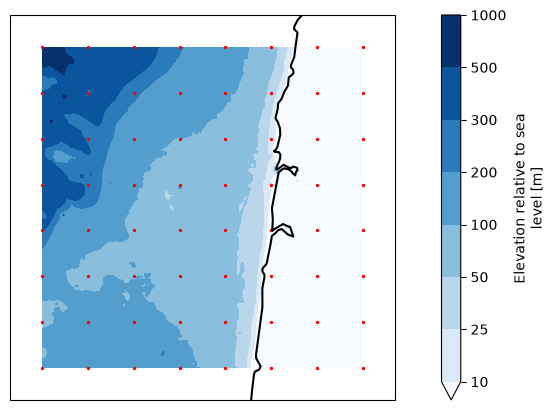

In [24]:
import matplotlib.pyplot as plt
from utils.plotting import detect_coordinate_system, plot_selected_bathy

# Get the projection from your bathy
coords = detect_coordinate_system(bathy)
proj = coords["proj"]
transform = coords["transform"]

# Create the plot with bathymetry and buoys
fig, ax = plt.subplots(figsize=(12, 5), subplot_kw={"projection": proj})
plot_selected_bathy(bathy=bathy, buoys=None, ax=ax)

ax.scatter(
    locations[:, 0],
    locations[:, 1],
    color="red",
    s=2,
    label="Output Locations",
    transform=coords["transform"],
)

## Build and Run SWAN Cases

> 🧘 **NOTE:** If directions and frequencies are used as default, You’re all set! The Bluemath Toolkit takes care of building and running the SWAN cases for you.

In [25]:
offshore_spectra = xr.open_dataset(
    "../../../../toolkit/data/outputs/offshore_spectra.nc"
)
freq = np.sort(offshore_spectra.spec.freq.values)
dir = np.sort(offshore_spectra.spec.dir.values)
print("freq", freq)
print("dir", dir)

freq [0.02   0.0325 0.0375 0.0425 0.0475 0.0525 0.0575 0.0625 0.0675 0.0725
 0.0775 0.0825 0.0875 0.0925 0.1    0.11   0.12   0.13   0.14   0.15
 0.16   0.17   0.18   0.19   0.2    0.21   0.22   0.23   0.24   0.25
 0.26   0.27   0.28   0.29   0.3    0.31   0.32   0.33   0.34   0.35
 0.365  0.385  0.405  0.425  0.445  0.465  0.485 ]
dir [  0   5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85
  90  95 100 105 110 115 120 125 130 135 140 145 150 155 160 165 170 175
 180 185 190 195 200 205 210 215 220 225 230 235 240 245 250 255 260 265
 270 275 280 285 290 295 300 305 310 315 320 325 330 335 340 345 350 355]


In [ ]:
from bluemath_tk.waves.binwaves import generate_swan_cases

swan_cases_df = (
    generate_swan_cases(
        # Different directions and frequencies can be specified. If not provided the model will use the default values.
        frequencies_array=freq,
        direction_range=(130, 400),
        direction_divisions=12,
    )
    .astype(float)
    .to_dataframe()
    .reset_index()
)
swan_cases_df["dir"] = swan_cases_df["dir"] % 360
swan_cases_df.head()

In [ ]:
from bluemath_tk.waves.binwaves import plot_selected_cases_grid

# Plot the cases grid. Specific directions sectors can be specified.
plot_selected_cases_grid(
    frequencies=np.unique(swan_cases_df["freq"]),
    directions=np.unique(swan_cases_df["dir"]),
    figsize=(8, 8),
)

In [ ]:
from bluemath_tk.wrappers.swan.swan_wrapper import generate_fixed_parameters

fixed_parameters = generate_fixed_parameters(grid_parameters, freq, dir)
fixed_parameters

In [ ]:
import os

from bluemath_tk.wrappers.swan.swan_wrapper import BinWavesWrapper

swan_wrapper = BinWavesWrapper(
    templates_dir="templates",
    metamodel_parameters=swan_cases_df.to_dict(orient="list"),
    fixed_parameters=fixed_parameters,
    output_dir="NEWPORT_CASES",
    depth_array=bathy.values,
    locations=locations.T,
)

In [ ]:
# Build the input files
swan_wrapper.build_cases(mode="one_by_one")
swan_cases_df.to_csv(os.path.join("NEWPORT_CASES", "swan_cases.csv"), index=False)

## Execute SWAN

> ⏰ **Note:** To monitor the progress of your runs, you can execute the following cell anytime to check how many SWAN cases have completed (100% simulation finished).  
> It may take a while for the first cases to finish, so feel free to run the cell multiple times to stay updated.  
> Once all cases have reached 100%, you can proceed with the rest of the code.  
> You can also run the next cells even if only a few cases have completed, to check that everything is working as expected.



In [ ]:
# Run the model

# swan_wrapper.run_cases_bulk(
#     launcher="sbatch --array=0-697%50 sbatch_example.sh"
# )
swan_wrapper.run_cases_in_background(launcher="swan_serial.exe", num_workers=4)

In [ ]:
swan_wrapper.monitor_cases(value_counts="simple")

In [ ]:
# Post-process the output files
cases_bulk_parameters = swan_wrapper.postprocess_cases()
cases_bulk_parameters

In [ ]:
from utils.plotting import plot_case_variables

plot_case_variables(
    data=cases_bulk_parameters.isel(case_num=10),
    step=20,
)

## Plot ALL pre-run cases

In [ ]:
from utils.plotting import plot_cases_grid

plot_cases_grid(
    data=cases_bulk_parameters.Hsig.where(
        cases_bulk_parameters.case_num.isin(
            swan_cases_df.where(swan_cases_df["hs"] == 1.0).dropna().index.values
        ),
        cases_bulk_parameters.Hsig * 10,
    ),
    cases_to_plot=[0, 117, 200],
    num_directions=len(swan_cases_df["dir"].unique()),
    num_frequencies=len(swan_cases_df["freq"].unique()),
)

## Extract kp coefficients

In [ ]:
from bluemath_tk.waves.binwaves import process_kp_coefficients

list_of_input_spectra = [
    os.path.join(case_dir, "input_spectra_N.bnd")
    for case_dir in swan_wrapper.cases_dirs
]
list_of_output_spectra = [
    os.path.join(case_dir, "output.spec") for case_dir in swan_wrapper.cases_dirs
]

kp_coefficients = process_kp_coefficients(
    list_of_input_spectra=list_of_input_spectra,
    list_of_output_spectra=list_of_output_spectra,
)
kp_coefficients

In [ ]:
kp_coefficients.to_dataset(name="kps").drop(["time"]).assign_coords(
    coord_x=(("site"), swan_wrapper.locations[:, 0]),
    coord_y=(("site"), swan_wrapper.locations[:, 1]),
).to_netcdf("outputs/kp_coefficients.nc")